### Group Project - Heathcare Informatics ###

### Data Cleaning ###

In [2]:
import pandas as pd

diabetes_data =pd.read_excel('Diabetes_data.xlsx')

# Diabetes dataset info
print("Shape of dataset: ", diabetes_data.shape)
print("\n")

diabetes_data.info()

Shape of dataset:  (442, 15)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PID             442 non-null    int64  
 1   age             441 non-null    float64
 2   sex             442 non-null    object 
 3   bmi             440 non-null    float64
 4   bp              442 non-null    float64
 5   s1              442 non-null    float64
 6   s2              441 non-null    float64
 7   s3              441 non-null    float64
 8   s4              442 non-null    float64
 9   s5              442 non-null    float64
 10  s6              442 non-null    float64
 11  target          442 non-null    int64  
 12  smoking_status  442 non-null    object 
 13  insurance       442 non-null    object 
 14  hypertension    442 non-null    object 
dtypes: float64(9), int64(2), object(4)
memory usage: 51.9+ KB


In [3]:
# View 5 rows
diabetes_data.head()

,PID,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target,smoking_status,insurance,hypertension
0,12301,58.046073,male,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151,never,Medicare,no
1,12302,54.849439,female,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75,former,Medicaid,no
2,12303,61.823913,male,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141,former,Medicaid,no
3,12304,47.874965,female,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206,current,Uninsured,yes
4,12305,55.430645,female,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135,current,Medicaid,no


### Descriptive column names for readability ###

In [4]:
# Descriptive column names for readability

new_column_names = {
    's1': 'total_cholesterol',
    's2': 'ldl',
    's3': 'hdl',
    's4': 'tch_hdl_ratio',
    's5': 'log_serum_triglycerides',
    's6': 'blood_sugar_level'
}
diabetes_data.rename(columns=new_column_names, inplace=True)



### Standardazing column names in snakecase ###

In [5]:
# Standardazing column names in snakecase
diabetes_data.rename(columns={
    'PID': 'pid'
}, inplace=True)

# Sanity Check
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   pid                      442 non-null    int64  
 1   age                      441 non-null    float64
 2   sex                      442 non-null    object 
 3   bmi                      440 non-null    float64
 4   bp                       442 non-null    float64
 5   total_cholesterol        442 non-null    float64
 6   ldl                      441 non-null    float64
 7   hdl                      441 non-null    float64
 8   tch_hdl_ratio            442 non-null    float64
 9   log_serum_triglycerides  442 non-null    float64
 10  blood_sugar_level        442 non-null    float64
 11  target                   442 non-null    int64  
 12  smoking_status           442 non-null    object 
 13  insurance                442 non-null    object 
 14  hypertension             4

### Finding Missing Values ###

In [6]:
# To find any values are misssing
is_missing = diabetes_data.isnull().values.any()
print("Any missing values:", is_missing)

Any missing values: True


In [7]:
# Number of missing values per column
missing_per_column = diabetes_data.isnull().sum()
print("Missing values per column:\n")
print(missing_per_column)

Missing values per column:

pid                        0
age                        1
sex                        0
bmi                        2
bp                         0
total_cholesterol          0
ldl                        1
hdl                        1
tch_hdl_ratio              0
log_serum_triglycerides    0
blood_sugar_level          0
target                     0
smoking_status             0
insurance                  0
hypertension               0
dtype: int64


### Finding Skewness ###

In [8]:
target_columns = ['age', 'bmi', 'ldl', 'hdl']

# Calculate skewness
skewness_results = diabetes_data[target_columns].skew()

print("Skewness results:")
print(skewness_results)    

Skewness results:
age    9.302845
bmi    0.601756
ldl    0.441844
hdl    0.795730
dtype: float64


### Skewness Analysis:
- As 'age' is higly right-skewed and 'bmi and hdl' are moderately right-skewed, the missing values will be replaced by Median.  

- 'ldl' is fairly symmetrical, so it can be replaced with Mean or Median. We'll be replacing with Median. 

### Age imputation by Median ###

In [9]:
# Missing age imputation by mean

# Create a copy for comparison
diabetes_data_original = diabetes_data.copy()

median_age = diabetes_data['age'].median()
print("Median age: ", int(median_age))
print("\n")

# Imputating age by Median
diabetes_data['age'] = diabetes_data['age'].fillna(median_age)

# Conerting Age Datatype to 'Int'
diabetes_data['age'] = diabetes_data['age'].round().astype(int)

# Printing values after replacing
replaced_age = diabetes_data[diabetes_data_original['age'].isnull()]
print("Rows after imputating 'age':\n", replaced_age)

Median age:  55


Rows after imputating 'age':
       pid  age     sex       bmi        bp  total_cholesterol       ldl  hdl  \
18  12319   55  female -0.010517 -0.036656          -0.037344 -0.019476  NaN   

    tch_hdl_ratio  log_serum_triglycerides  blood_sugar_level  target  \
18      -0.002592                -0.018114          -0.017646      97   

   smoking_status  insurance hypertension  
18         former  Uninsured           no  


### BMI imputation by Median ###

In [10]:
# Missing bmi imputation by median

# Create a copy for comparison
diabetes_data_original = diabetes_data.copy()

median_bmi = diabetes_data['bmi'].median()
print("Median BMI: ", median_bmi)
print("\n")

#imputating bmi
diabetes_data['bmi'] = diabetes_data['bmi'].fillna(median_bmi)

# Printing values after replacing
replaced_bmi = diabetes_data[diabetes_data_original['bmi'].isnull()]
print("Rows after imputating 'bmi':\n", replaced_bmi)


Median BMI:  -0.007283766209687899


Rows after imputating 'bmi':
       pid  age     sex       bmi        bp  total_cholesterol       ldl  \
10  12311   47  female -0.007284  0.008101          -0.103389 -0.090561   
67  12368   58    male -0.007284 -0.017135          -0.005697  0.008394   

         hdl  tch_hdl_ratio  log_serum_triglycerides  blood_sugar_level  \
10 -0.013948      -0.076395                -0.062917          -0.034215   
67 -0.013948      -0.001854                -0.011897           0.003064   

    target smoking_status  insurance hypertension  
10     101          never  Uninsured           no  
67      97        current   Medicaid           no  


### Analysis:
In a real-world, BMI cannot be negative. But the given dataset has been pre-processed and scaled. 
A negative value simply means that the person's BMI is below the average BMI of the group

### LDL imputation by median ###

In [11]:
# LDL imputation by median

# Create a copy for comparison
diabetes_data_original = diabetes_data.copy()

median_ldl = diabetes_data['ldl'].median()
print("Median LDL: ", median_ldl)
print("\n")

#imputating ldl
diabetes_data['ldl'] = diabetes_data['ldl'].fillna(median_ldl)

# Printing values after replacing
replaced_ldl = diabetes_data[diabetes_data_original['ldl'].isnull()]
print("Rows after imputating 'ldl':\n", replaced_ldl)

Median LDL:  -0.003819065120535


Rows after imputating 'ldl':
       pid  age     sex       bmi        bp  total_cholesterol       ldl  \
63  12364   52  female -0.037463 -0.060756           0.020446 -0.003819   

         hdl  tch_hdl_ratio  log_serum_triglycerides  blood_sugar_level  \
63 -0.013948      -0.002592                -0.030748          -0.071494   

    target smoking_status  insurance hypertension  
63     128          never  Uninsured           no  


### HDL imputation by median ###

In [12]:
# HDL imputation by median

# Create a copy for comparison
diabetes_data_original = diabetes_data.copy()

median_hdl = diabetes_data['hdl'].median()
print("Median HDL: ", median_hdl)
print("\n")

#imputating hdl
diabetes_data['hdl'] = diabetes_data['hdl'].fillna(median_hdl)

# Printing values after replacing
replaced_hdl = diabetes_data[diabetes_data_original['hdl'].isnull()]
print("Rows after imputating 'hdl':\n", replaced_hdl)

Median HDL:  -0.006584467611155497


Rows after imputating 'hdl':
       pid  age     sex       bmi        bp  total_cholesterol       ldl  \
18  12319   55  female -0.010517 -0.036656          -0.037344 -0.019476   

         hdl  tch_hdl_ratio  log_serum_triglycerides  blood_sugar_level  \
18 -0.006584      -0.002592                -0.018114          -0.017646   

    target smoking_status  insurance hypertension  
18      97         former  Uninsured           no  


### Analysis:
Just like BMI, the LDL and HDL values in this dataset are also pre-processed and scaled

### Sanity check, to verify NO missing vlaues per column ### 

In [13]:
# Number of missing values per column
missing_per_column = diabetes_data.isnull().sum()
print("Missing values per column:\n", missing_per_column)

Missing values per column:
 pid                        0
age                        0
sex                        0
bmi                        0
bp                         0
total_cholesterol          0
ldl                        0
hdl                        0
tch_hdl_ratio              0
log_serum_triglycerides    0
blood_sugar_level          0
target                     0
smoking_status             0
insurance                  0
hypertension               0
dtype: int64


### Verification for duplicate rows ###

In [14]:
# To check whether any duplicate rows are there
count = diabetes_data.duplicated().sum()
print("Duplicated rows count: ",count)

Duplicated rows count:  0


### Exploratory Data Analysis ###

### Descriptive statistics ###

In [15]:
# Descriptive statistics 
diabetes_data.describe()

,pid,age,bmi,bp,total_cholesterol,ldl,hdl,tch_hdl_ratio,log_serum_triglycerides,blood_sugar_level,target
count,442.000000,442.000000,442.000000,4.420000e+02,4.420000e+02,442.000000,442.000000,4.420000e+02,442.000000,442.000000,442.000000
mean,12521.500000,55.221719,0.000190,-4.722216e-17,-1.406617e-17,-0.000107,0.000050,-7.535450e-18,0.022624,0.045241,152.133484
std,127.738666,5.910955,0.047448,4.761905e-02,4.761905e-02,0.047574,0.047600,4.761905e-02,0.479737,0.955821,77.093005
min,12301.000000,46.000000,-0.090275,-1.123988e-01,-1.267807e-01,-0.115613,-0.102307,-7.639450e-02,-0.126097,-0.137767,25.000000
25%,12411.250000,52.000000,-0.034229,-3.665608e-02,-3.424784e-02,-0.030358,-0.035117,-3.949338e-02,-0.033246,-0.033179,87.000000
50%,12521.500000,55.000000,-0.007284,-5.670422e-03,-4.320866e-03,-0.003819,-0.006584,-2.592262e-03,-0.001947,-0.001078,140.500000
75%,12631.750000,58.000000,0.031248,3.564379e-02,2.835801e-02,0.029140,0.029312,3.430886e-02,0.032432,0.027917,211.500000
max,12742.000000,150.000000,0.170555,1.320436e-01,1.539137e-01,0.198788,0.181179,1.852344e-01,10.036060,20.070000,346.000000


### Descriptive health statistics by Gender ###

In [16]:
#Find the descriptive health statistics by gender
# filtering numeric columns
numeric_cols = [
    'bmi', 'total_cholesterol', 'ldl', 'hdl',
    'tch_hdl_ratio', 'log_serum_triglycerides',
    'blood_sugar_level', 'target'
]
gender_group = diabetes_data.groupby('sex')

gender_group[numeric_cols].agg(['mean', 'median', 'std'])


bmi                     total_cholesterol                      \
            mean    median       std              mean    median       std   
sex                                                                          
female -0.003610 -0.008362  0.048991         -0.001575 -0.002945  0.045744   
male    0.004504 -0.005128  0.045366          0.001788 -0.004321  0.049713   

             ldl                           hdl  ... tch_hdl_ratio  \
            mean    median       std      mean  ...           std   
sex                                             ...                 
female -0.006569 -0.011335  0.045387  0.017017  ...      0.043070   
male    0.007229  0.001504  0.049026 -0.019212  ...      0.047029   

       log_serum_triglycerides                     blood_sugar_level  \
                          mean    median       std              mean   
sex                                                                    
female               -0.006693 -0.018114  0.046812         -0.009291   
male                  0.055907  0.010227  0.698650          0.107150   

                                target                    
          median       std        mean median        std  
sex                                                       
female -0.009362  0.047233  149.021277  140.0  75.905781  
male    0.007207  1.394999  155.666667  141.0  78.453313  

[2 rows x 24 columns]

### Descriptive health statistics by insurance ###

In [73]:
#Find the descriptive health statistics by insurance

ins_group = diabetes_data.groupby('insurance')

ins_group[numeric_cols].agg(['mean', 'median', 'std'])

bmi                     total_cholesterol                      \
               mean    median       std              mean    median       std   
insurance                                                                       
Medicaid   0.002630 -0.006745  0.048106         -0.001937 -0.002257  0.038953   
Medicare  -0.003416 -0.005667  0.046263          0.001693 -0.002257  0.050779   
Private   -0.001540 -0.008362  0.049485         -0.000099 -0.006385  0.052669   
Uninsured  0.002965 -0.006745  0.046752          0.000205 -0.005697  0.048537   

                ldl                           hdl  ... tch_hdl_ratio  \
               mean    median       std      mean  ...           std   
insurance                                          ...                 
Medicaid  -0.001757 -0.002723  0.041371  0.001794  ...      0.049538   
Medicare   0.000254 -0.011961  0.050564  0.004282  ...      0.045707   
Private    0.001401 -0.004759  0.054644 -0.006292  ...      0.054353   
Uninsured  0.000014 -0.001157  0.044771 -0.001433  ...      0.041946   

          log_serum_triglycerides                     blood_sugar_level  \
                             mean    median       std              mean   
insurance                                                                 
Medicaid                -0.000975 -0.003301  0.043053          0.004528   
Medicare                 0.080427  0.000710  0.902658          0.000893   
Private                  0.000101 -0.012931  0.051666          0.227756   
Uninsured                0.001151 -0.001496  0.047421         -0.005983   

                                   target                    
             median       std        mean median        std  
insurance                                                    
Medicaid   0.003064  0.052506  159.112069  156.5  74.495728  
Medicare  -0.001078  0.046616  157.661290  143.0  79.218529  
Private    0.000993  2.140036  147.693182  135.0  75.697425  
Uninsured -0.007291  0.042623  142.447368  125.5  78.171594  

[4 rows x 24 columns]

### Descriptive health statistics by smoking status ###

In [74]:
#Find the descriptive health statistics by smoking status

smoker_group = diabetes_data.groupby('smoking_status')

smoker_group[numeric_cols].agg(['mean', 'median', 'std'])

bmi                     total_cholesterol            \
                    mean    median       std              mean    median   
smoking_status                                                             
current        -0.001388 -0.005128  0.048501         -0.004653 -0.005697   
former          0.000269 -0.007284  0.046780          0.002740 -0.004321   
never           0.001562 -0.008362  0.047250          0.002072  0.000495   

                               ldl                           hdl  ...  \
                     std      mean    median       std      mean  ...   
smoking_status                                                    ...   
current         0.044228 -0.004384 -0.005072  0.042380  0.001125  ...   
former          0.047683  0.001254 -0.009143  0.051895  0.003947  ...   
never           0.050432  0.002708 -0.000374  0.048494 -0.003992  ...   

               tch_hdl_ratio log_serum_triglycerides                      \
                         std                    mean    median       std   
smoking_status                                                             
current             0.039288               -0.002020 -0.004222  0.045035   
former              0.053456                0.076951 -0.005142  0.885093   
never               0.049503                0.002283 -0.000612  0.048399   

               blood_sugar_level                          target         \
                            mean    median       std        mean median   
smoking_status                                                            
current                -0.004747 -0.001078  0.043654  154.617450  141.0   
former                  0.153228  0.003064  1.767916  146.031008  138.0   
never                   0.005716  0.003064  0.050313  154.676829  141.5   

                           
                      std  
smoking_status             
current         76.489321  
former          76.921423  
never           77.971596  

[3 rows x 24 columns]

### Value counts for categorical variables ###

In [76]:
# Value counts for categorical variables
categorical_cols = ['sex', 'smoking_status', 'insurance', 'hypertension']

for col in categorical_cols:
    print(f"\n{col.upper()} distribution:")
    print(diabetes_data[col].value_counts())


SEX distribution:
sex
female    235
male      207
Name: count, dtype: int64

SMOKING_STATUS distribution:
smoking_status
never      164
current    149
former     129
Name: count, dtype: int64

INSURANCE distribution:
insurance
Medicare     124
Medicaid     116
Uninsured    114
Private       88
Name: count, dtype: int64

HYPERTENSION distribution:
hypertension
no     321
yes    121
Name: count, dtype: int64


### Outlier Correction for AGE ###

=== Age Verification Check For Outlier Correction ===
Max age: 150.00
Min age: 46.00
Mean age: 55.22
Std age: 5.91




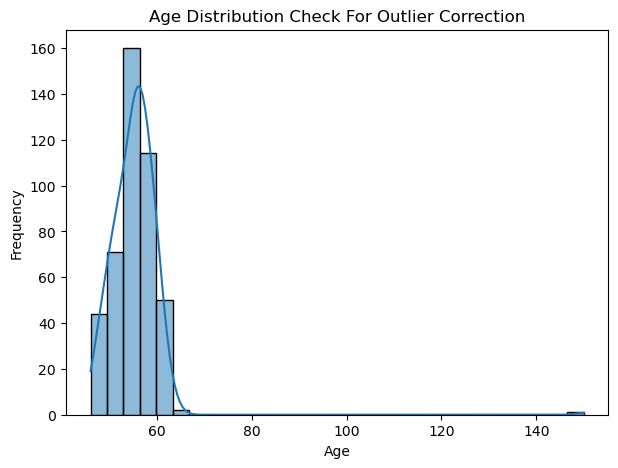

In [77]:
# Outlier Correction for AGE
import matplotlib.pyplot as plt
import seaborn as sns

# Verify outlier correction
print("=== Age Verification Check For Outlier Correction ===")
print(f"Max age: {diabetes_data['age'].max():.2f}")
print(f"Min age: {diabetes_data['age'].min():.2f}")
print(f"Mean age: {diabetes_data['age'].mean():.2f}")
print(f"Std age: {diabetes_data['age'].std():.2f}")
print("\n")

# Visual confirmation Before 
plt.figure(figsize=(7,5))
sns.histplot(diabetes_data['age'], bins=30, kde=True)
plt.title('Age Distribution Check For Outlier Correction')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

The above graph clearly shows outliers in age. So, need to remove them.

Age outliers detected:
 Empty DataFrame
Columns: [pid, age]
Index: []


Max age after correction: 64.0
Records with age > 120: 0


=== Age Verification After Outlier Correction ===
Max age: 64.00
Min age: 46.00
Mean age: 55.01
Std age: 3.81


Records with age > 120: 0




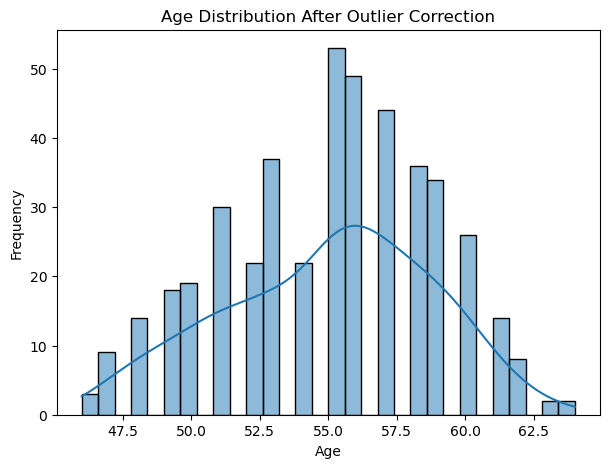

In [79]:
# Age seems to have Outliers. So, correct that.
# STEP 1 - DETECT FIRST
Q1 = diabetes_data['age'].quantile(0.25)
Q3 = diabetes_data['age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
age_outliers = diabetes_data[(diabetes_data['age'] < lower_bound) | (diabetes_data['age'] > upper_bound)]
print("Age outliers detected:\n", age_outliers[['pid', 'age']])
print("\n")

# STEP 2 - THEN REPLACE
mean_age_clean = diabetes_data[diabetes_data['age'] <= 120]['age'].mean()
diabetes_data['age'] = diabetes_data['age'].apply(lambda x: mean_age_clean if x > 120 else x)

# STEP 3 - THEN VERIFY
print("Max age after correction:", diabetes_data['age'].max())
print(f"Records with age > 120: {len(diabetes_data[diabetes_data['age'] > 120])}")
print("\n")

# Verify outlier correction
print("=== Age Verification After Outlier Correction ===")
print(f"Max age: {diabetes_data['age'].max():.2f}")
print(f"Min age: {diabetes_data['age'].min():.2f}")
print(f"Mean age: {diabetes_data['age'].mean():.2f}")
print(f"Std age: {diabetes_data['age'].std():.2f}")
print("\n")

# Confirm no more impossible values
impossible_ages = diabetes_data[diabetes_data['age'] > 120]
print(f"Records with age > 120: {len(impossible_ages)}")
print("\n")

# Visual confirmation
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
sns.histplot(diabetes_data['age'], bins=30, kde=True)
plt.title('Age Distribution After Outlier Correction')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Outlier Detection for BMI ###

=== BMI Verification Check For Outlier Correction ===
Max BMI: 0.1705552259806441
Min BMI: -0.09027529589850945
Mean BMI: 0.00019020213068462305
Std BMI: 0.047448417666891105




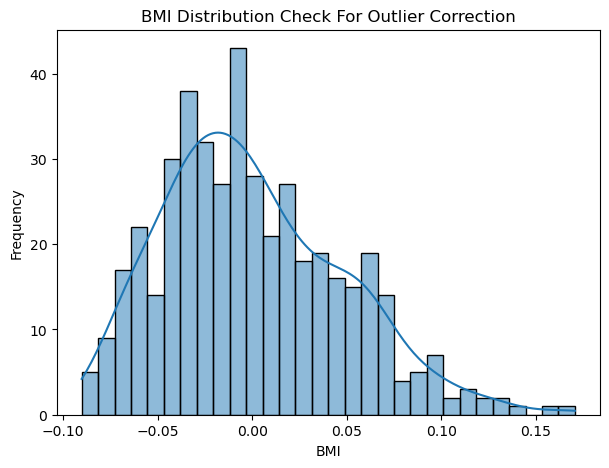

In [80]:
# Outlier Detection for BMI
import matplotlib.pyplot as plt
import seaborn as sns

# Verify outlier correction
print("=== BMI Verification Check For Outlier Correction ===")
print(f"Max BMI: {diabetes_data['bmi'].max()}")
print(f"Min BMI: {diabetes_data['bmi'].min()}")
print(f"Mean BMI: {diabetes_data['bmi'].mean()}")
print(f"Std BMI: {diabetes_data['bmi'].std()}")
print("\n")

# Visual confirmation Before 
plt.figure(figsize=(7,5))
sns.histplot(diabetes_data['bmi'], bins=30, kde=True)
plt.title('BMI Distribution Check For Outlier Correction')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

### Outlier Detection for BP ###

=== BP Verification Before Outlier Correction ===
Max BP: 0.1320436167412131
Min BP: -0.1123988025440845
Mean BP: -4.722215579853607e-17
Std BP: 0.04761904761904762




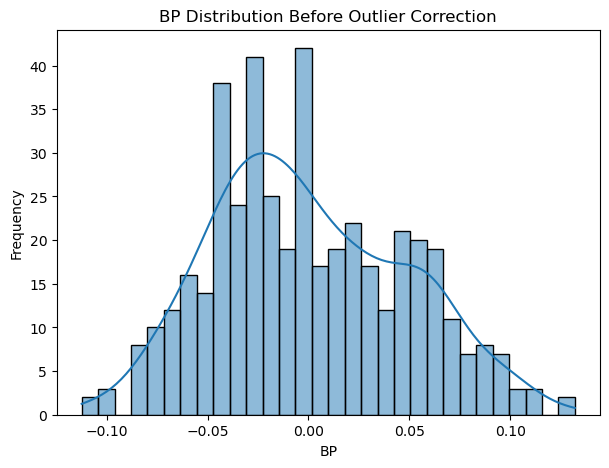

In [81]:
# Outlier Detection for BP
import matplotlib.pyplot as plt
import seaborn as sns

# Verify outlier correction
print("=== BP Verification Before Outlier Correction ===")
print(f"Max BP: {diabetes_data['bp'].max()}")
print(f"Min BP: {diabetes_data['bp'].min()}")
print(f"Mean BP: {diabetes_data['bp'].mean()}")
print(f"Std BP: {diabetes_data['bp'].std()}")
print("\n")

# Visual confirmation Before 
plt.figure(figsize=(7,5))
sns.histplot(diabetes_data['bp'], bins=30, kde=True)
plt.title('BP Distribution Before Outlier Correction')
plt.xlabel('BP')
plt.ylabel('Frequency')
plt.show()

### Outlier Detection for Total Cholesterol ###

=== Total Cholesterol Verification Before Outlier Correction ===
Max Total Cholesterol: 0.1539137131565154
Min Total Cholesterol: -0.1267806699165132
Mean Total Cholesterol: -1.406617406764904e-17
Std Total Cholesterol: 0.047619047619047554




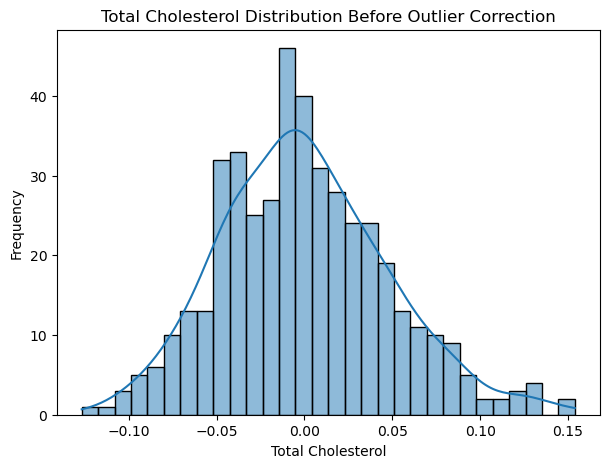

In [82]:
# Outlier Detection for Total Cholesterol
import matplotlib.pyplot as plt
import seaborn as sns

# Verify outlier correction
print("=== Total Cholesterol Verification Before Outlier Correction ===")
print(f"Max Total Cholesterol: {diabetes_data['total_cholesterol'].max()}")
print(f"Min Total Cholesterol: {diabetes_data['total_cholesterol'].min()}")
print(f"Mean Total Cholesterol: {diabetes_data['total_cholesterol'].mean()}")
print(f"Std Total Cholesterol: {diabetes_data['total_cholesterol'].std()}")
print("\n")

# Visual confirmation Before 
plt.figure(figsize=(7,5))
sns.histplot(diabetes_data['total_cholesterol'], bins=30, kde=True)
plt.title('Total Cholesterol Distribution Before Outlier Correction')
plt.xlabel('Total Cholesterol')
plt.ylabel('Frequency')
plt.show()

### Outlier Detection for LDL ###

=== LDL Verification Before Outlier Correction ===
Max LDL: 0.1987879896572941
Min LDL: -0.115613065979399
Mean LDL: -0.00010698058310000504
Std LDL: 0.047574269490166694




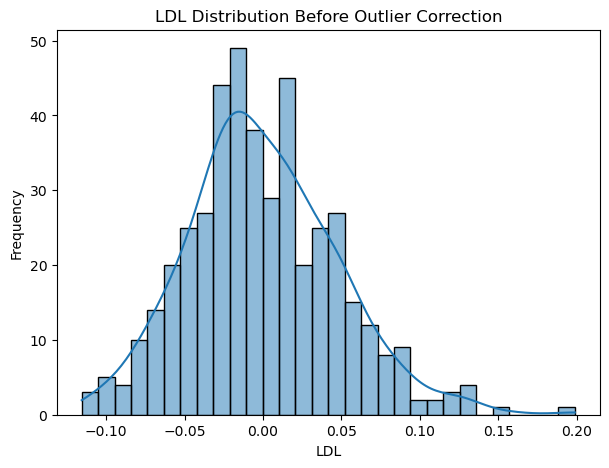

In [83]:
# Outlier Detection for LDL
import matplotlib.pyplot as plt
import seaborn as sns

# Verify outlier correction
print("=== LDL Verification Before Outlier Correction ===")
print(f"Max LDL: {diabetes_data['ldl'].max()}")
print(f"Min LDL: {diabetes_data['ldl'].min()}")
print(f"Mean LDL: {diabetes_data['ldl'].mean()}")
print(f"Std LDL: {diabetes_data['ldl'].std()}")
print("\n")

# Visual confirmation Before 
plt.figure(figsize=(7,5))
sns.histplot(diabetes_data['ldl'], bins=30, kde=True)
plt.title('LDL Distribution Before Outlier Correction')
plt.xlabel('LDL')
plt.ylabel('Frequency')
plt.show()

### Outlier Detection for HDL ###

=== HDL Verification Before Outlier Correction ===
Max HDL: 0.1811790603972785
Min HDL: -0.102307050517416
Mean HDL: 4.9976983765881193e-05
Std HDL: 0.047600473426765405




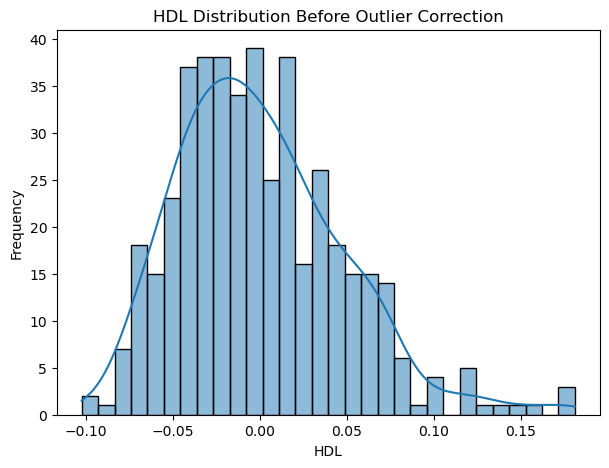

In [84]:
# Outlier Detection for HDL
import matplotlib.pyplot as plt
import seaborn as sns

# Verify outlier correction
print("=== HDL Verification Before Outlier Correction ===")
print(f"Max HDL: {diabetes_data['hdl'].max()}")
print(f"Min HDL: {diabetes_data['hdl'].min()}")
print(f"Mean HDL: {diabetes_data['hdl'].mean()}")
print(f"Std HDL: {diabetes_data['hdl'].std()}")
print("\n")

# Visual confirmation Before 
plt.figure(figsize=(7,5))
sns.histplot(diabetes_data['hdl'], bins=30, kde=True)
plt.title('HDL Distribution Before Outlier Correction')
plt.xlabel('HDL')
plt.ylabel('Frequency')
plt.show()

### Outlier Detection for TCH HDL Ratio ###

=== TCH HDL Ratio Verification Before Outlier Correction ===
Max TCH HDL Ratio: 0.1852344432601987
Min TCH HDL Ratio: -0.0763945037500033
Mean TCH HDL Ratio: -7.535450393383415e-18
Std TCH HDL Ratio: 0.047619047619047554




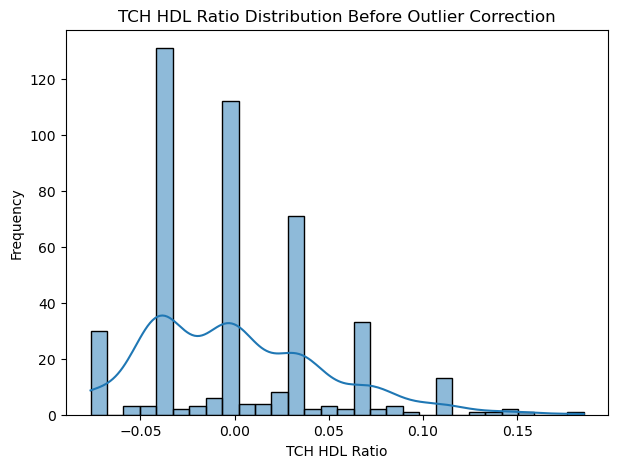

In [85]:
# Outlier Detection for TCH HDL Ratio
import matplotlib.pyplot as plt
import seaborn as sns

# Verify outlier correction
print("=== TCH HDL Ratio Verification Before Outlier Correction ===")
print(f"Max TCH HDL Ratio: {diabetes_data['tch_hdl_ratio'].max()}")
print(f"Min TCH HDL Ratio: {diabetes_data['tch_hdl_ratio'].min()}")
print(f"Mean TCH HDL Ratio: {diabetes_data['tch_hdl_ratio'].mean()}")
print(f"Std TCH HDL Ratio: {diabetes_data['tch_hdl_ratio'].std()}")
print("\n")

# Visual confirmation Before 
plt.figure(figsize=(7,5))
sns.histplot(diabetes_data['tch_hdl_ratio'], bins=30, kde=True)
plt.title('TCH HDL Ratio Distribution Before Outlier Correction')
plt.xlabel('TCH HDL Ratio')
plt.ylabel('Frequency')
plt.show()

### Outlier Detection for Log Serum Triglyerides ###

Age outliers detected:
       pid  log_serum_triglycerides
15  12316                 10.03606


Max log_serum_triglycerides after correction: 0.1335972819219136
Records with log_serum_triglycerides > 1.0: 0


=== Age Verification After Outlier Correction ===
Max log_serum_triglycerides: 0.1335972819219136
Min log_serum_triglycerides: -0.1260971208333047
Mean log_serum_triglycerides: -8.176946484189324e-05
Std log_serum_triglycerides: 0.047588006637039604


Records with log_serum_triglycerides > 1.0: 0




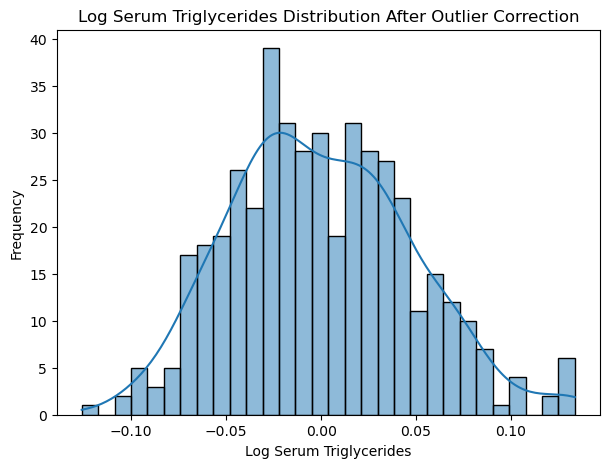

In [88]:
# Log Serum Triglycerides seems to have Outliers. So, correct that.
# STEP 1 - DETECT FIRST
Q1 = diabetes_data['log_serum_triglycerides'].quantile(0.25)
Q3 = diabetes_data['log_serum_triglycerides'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.80 * IQR
upper_bound = Q3 + 1.80 * IQR
log_serum_triglycerides_outliers = diabetes_data[(diabetes_data['log_serum_triglycerides'] < lower_bound) | (diabetes_data['log_serum_triglycerides'] > upper_bound)]
print("Age outliers detected:\n", log_serum_triglycerides_outliers[['pid', 'log_serum_triglycerides']])
print("\n")

# STEP 2 - THEN REPLACE
mean_log_serum_triglycerides_clean = diabetes_data[diabetes_data['log_serum_triglycerides'] <= 1.0]['log_serum_triglycerides'].mean()
diabetes_data['log_serum_triglycerides'] = diabetes_data['log_serum_triglycerides'].apply(lambda x: mean_log_serum_triglycerides_clean if x > 1.0 else x)

# STEP 3 - THEN VERIFY
print("Max log_serum_triglycerides after correction:", diabetes_data['log_serum_triglycerides'].max())
print(f"Records with log_serum_triglycerides > 1.0: {len(diabetes_data[diabetes_data['log_serum_triglycerides'] > 1.0])}")
print("\n")

# Verify outlier correction
print("=== Age Verification After Outlier Correction ===")
print(f"Max log_serum_triglycerides: {diabetes_data['log_serum_triglycerides'].max()}")
print(f"Min log_serum_triglycerides: {diabetes_data['log_serum_triglycerides'].min()}")
print(f"Mean log_serum_triglycerides: {diabetes_data['log_serum_triglycerides'].mean()}")
print(f"Std log_serum_triglycerides: {diabetes_data['log_serum_triglycerides'].std()}")
print("\n")

# Confirm no more impossible values
impossible_log_serum_triglyceridess = diabetes_data[diabetes_data['log_serum_triglycerides'] > 1.0]
print(f"Records with log_serum_triglycerides > 1.0: {len(impossible_log_serum_triglyceridess)}")
print("\n")

# Visual confirmation
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
sns.histplot(diabetes_data['log_serum_triglycerides'], bins=30, kde=True)
plt.title('Log Serum Triglycerides Distribution After Outlier Correction')
plt.xlabel('Log Serum Triglycerides')
plt.ylabel('Frequency')
plt.show()

### Outlier Detection for Log Serum Triglyerides ###

=== Log Serum Triglyerides Verification Before Outlier Correction ===
Max Log Serum Triglyerides: 0.1335972819219136
Min Log Serum Triglyerides: -0.1260971208333047
Mean Log Serum Triglyerides: -8.176946484189324e-05
Std Log Serum Triglyerides: 0.047588006637039604




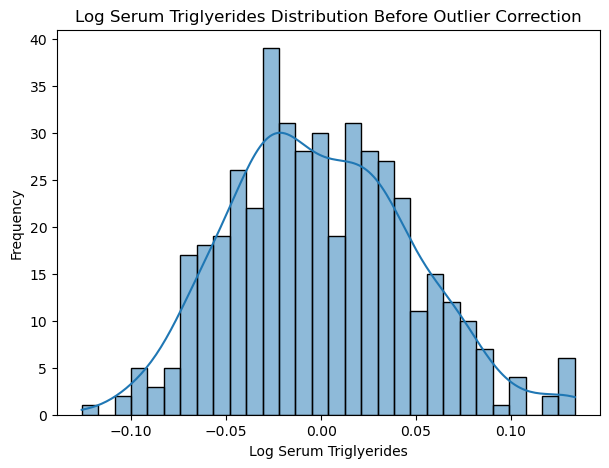

In [89]:
# Outlier Detection for Log Serum Triglyerides
import matplotlib.pyplot as plt
import seaborn as sns

# Verify outlier correction
print("=== Log Serum Triglyerides Verification Before Outlier Correction ===")
print(f"Max Log Serum Triglyerides: {diabetes_data['log_serum_triglycerides'].max()}")
print(f"Min Log Serum Triglyerides: {diabetes_data['log_serum_triglycerides'].min()}")
print(f"Mean Log Serum Triglyerides: {diabetes_data['log_serum_triglycerides'].mean()}")
print(f"Std Log Serum Triglyerides: {diabetes_data['log_serum_triglycerides'].std()}")
print("\n")

# Visual confirmation Before 
plt.figure(figsize=(7,5))
sns.histplot(diabetes_data['log_serum_triglycerides'], bins=30, kde=True)
plt.title('Log Serum Triglyerides Distribution Before Outlier Correction')
plt.xlabel('Log Serum Triglyerides')
plt.ylabel('Frequency')
plt.show()

###  Outlier Detection for Blood Sugar Level ####

=== Blood Sugar Level Verification Before Outlier Correction ===
Max Blood Sugar Level: 20.07
Min Blood Sugar Level: -0.137767225690003
Mean Blood Sugar Level: 0.045240994961614135
Std Blood Sugar Level: 0.9558209756164813




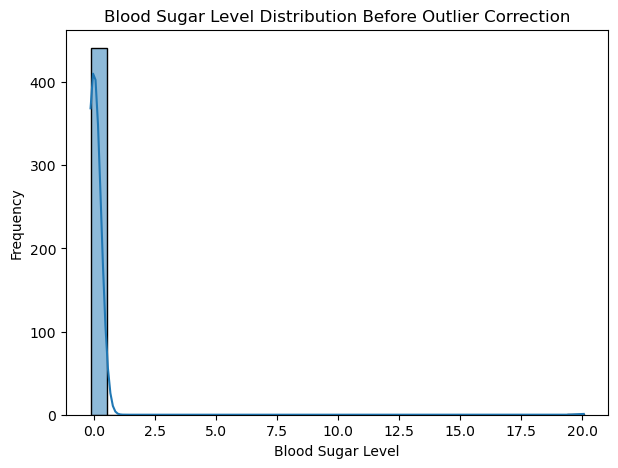

In [91]:
# Outlier Detection for Blood Sugar Level
import matplotlib.pyplot as plt
import seaborn as sns

# Verify outlier correction
print("=== Blood Sugar Level Verification Before Outlier Correction ===")
print(f"Max Blood Sugar Level: {diabetes_data['blood_sugar_level'].max()}")
print(f"Min Blood Sugar Level: {diabetes_data['blood_sugar_level'].min()}")
print(f"Mean Blood Sugar Level: {diabetes_data['blood_sugar_level'].mean()}")
print(f"Std Blood Sugar Level: {diabetes_data['blood_sugar_level'].std()}")
print("\n")

# Visual confirmation Before 
plt.figure(figsize=(7,5))
sns.histplot(diabetes_data['blood_sugar_level'], bins=30, kde=True)
plt.title('Blood Sugar Level Distribution Before Outlier Correction')
plt.xlabel('Blood Sugar Level')
plt.ylabel('Frequency')
plt.show()

### Outlier correction for Blood Sugar Level ###

Age outliers detected:
        pid  blood_sugar_level
123  12424              20.07


Max blood_sugar_level after correction: 0.1356118306890711
Records with blood_sugar_level > 1.0: 0


=== Age Verification After Outlier Correction ===
Max blood_sugar_level: 0.1356118306890711
Min blood_sugar_level: -0.137767225690003
Mean blood_sugar_level: -0.0001666218298561224
Std blood_sugar_level: 0.04749002551521243


Records with blood_sugar_level > 1.0: 0




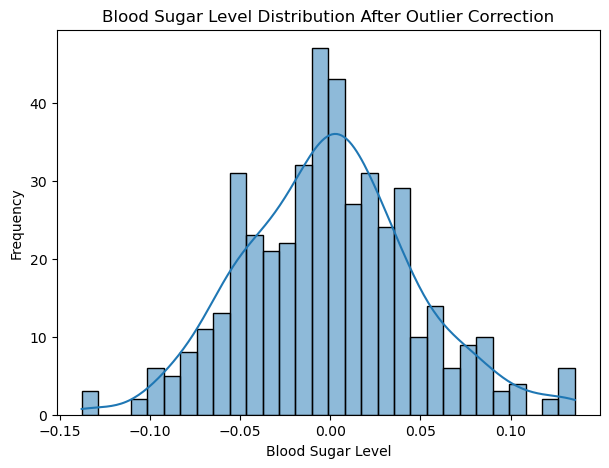

In [92]:
# Blood sugar level seems to have Outliers. So, correct that.
# STEP 1 - DETECT FIRST
Q1 = diabetes_data['blood_sugar_level'].quantile(0.25)
Q3 = diabetes_data['blood_sugar_level'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.80 * IQR
upper_bound = Q3 + 1.80 * IQR
blood_sugar_level_outliers = diabetes_data[(diabetes_data['blood_sugar_level'] < lower_bound) | (diabetes_data['blood_sugar_level'] > upper_bound)]
print("Age outliers detected:\n", blood_sugar_level_outliers[['pid', 'blood_sugar_level']])
print("\n")

# STEP 2 - THEN REPLACE
mean_blood_sugar_level_clean = diabetes_data[diabetes_data['blood_sugar_level'] <= 1.0]['blood_sugar_level'].mean()
diabetes_data['blood_sugar_level'] = diabetes_data['blood_sugar_level'].apply(lambda x: mean_blood_sugar_level_clean if x > 1.0 else x)

# STEP 3 - THEN VERIFY
print("Max blood_sugar_level after correction:", diabetes_data['blood_sugar_level'].max())
print(f"Records with blood_sugar_level > 1.0: {len(diabetes_data[diabetes_data['blood_sugar_level'] > 1.0])}")
print("\n")

# Verify outlier correction
print("=== Age Verification After Outlier Correction ===")
print(f"Max blood_sugar_level: {diabetes_data['blood_sugar_level'].max()}")
print(f"Min blood_sugar_level: {diabetes_data['blood_sugar_level'].min()}")
print(f"Mean blood_sugar_level: {diabetes_data['blood_sugar_level'].mean()}")
print(f"Std blood_sugar_level: {diabetes_data['blood_sugar_level'].std()}")
print("\n")

# Confirm no more impossible values
impossible_blood_sugar_levels = diabetes_data[diabetes_data['blood_sugar_level'] > 1.0]
print(f"Records with blood_sugar_level > 1.0: {len(impossible_blood_sugar_levels)}")
print("\n")

# Visual confirmation
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
sns.histplot(diabetes_data['blood_sugar_level'], bins=30, kde=True)
plt.title('Blood Sugar Level Distribution After Outlier Correction')
plt.xlabel('Blood Sugar Level')
plt.ylabel('Frequency')
plt.show()

### Outlier Detection for Target ###

=== Target Verification Before Outlier Correction ===
Max Target: 346
Min Target: 25
Mean Target: 152.13348416289594
Std Target: 77.09300453299109




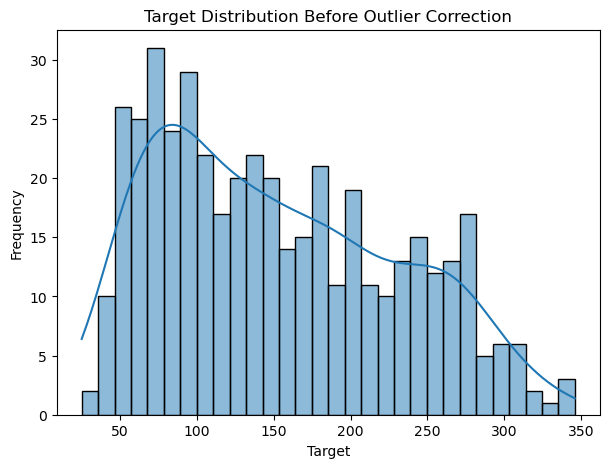

In [93]:
# Outlier Detection for Target
import matplotlib.pyplot as plt
import seaborn as sns

# Verify outlier correction
print("=== Target Verification Before Outlier Correction ===")
print(f"Max Target: {diabetes_data['target'].max()}")
print(f"Min Target: {diabetes_data['target'].min()}")
print(f"Mean Target: {diabetes_data['target'].mean()}")
print(f"Std Target: {diabetes_data['target'].std()}")
print("\n")

# Visual confirmation Before 
plt.figure(figsize=(7,5))
sns.histplot(diabetes_data['target'], bins=30, kde=True)
plt.title('Target Distribution Before Outlier Correction')
plt.xlabel('Target')
plt.ylabel('Frequency')
plt.show()

### Data Visualization ###

### Age Distribution of Diabetes Patients ###

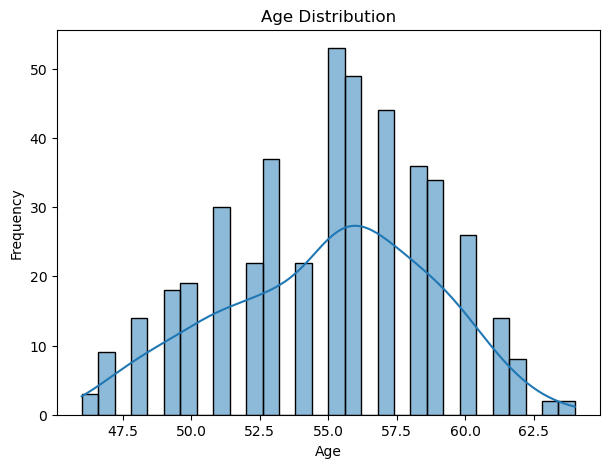

In [94]:
# Age Distribution of Diabetes Patients
# PURPOSE: To understand the age range and spread of patients
#          in the dataset and confirm the population is 
#          clinically appropriate for diabetes research.

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
sns.histplot(diabetes_data['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

X-axis: Age (years) — ranges from ~46 to 64 after outlier correction
Y-axis: Frequency — how many patients fall in each age range
Shows that most patients are between 52–60 years old, peaking around 55.
Confirms the dataset represents a middle-to-older adult population, which is clinically consistent with Type 2 diabetes. 


 ### Clinical Insights
Most patients in this dataset are between 52–60 years old, peaking around age 55.
This matches real-world diabetes demographics, where the disease most commonly
affects middle-to-older adults.
The fact that no patients are younger than 46 or older than 64 (after cleaning)
tells us this dataset represents a very specific age window.
Age alone is not enough to predict diabetes risk —
it simply confirms we are looking at the right population for this type of study

### Age vs. Diabetes Progression Score ###

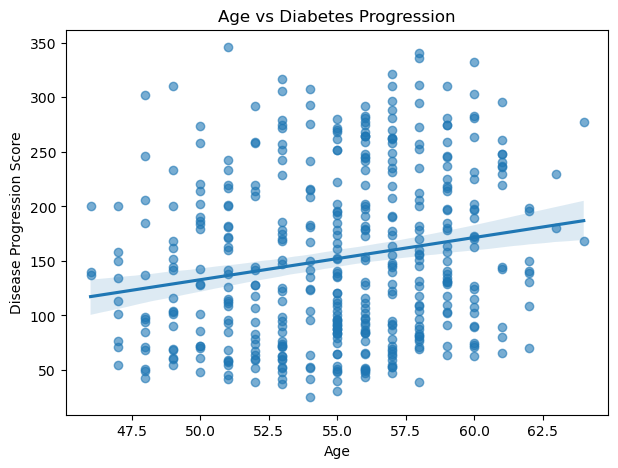

In [95]:
# Age vs. Diabetes Progression Score
# PURPOSE: To determine whether older patients tend to have
#          worse diabetes outcomes, and how strong that
#          relationship is compared to other risk factors.

plt.figure(figsize=(7,5))
sns.regplot(
    data=diabetes_data,
    x='age',
    y='target',
    scatter_kws={'alpha':0.6}
)
plt.title('Age vs Diabetes Progression')
plt.xlabel('Age')
plt.ylabel('Disease Progression Score')
plt.show()

X-axis: Age (years) Y-axis: Disease Progression Score — a number measuring how much diabetes worsened over one year
Eeach dot is one patient. The regression line slopes gently upward, meaning older patients tend to have slightly higher progression scores, 
The wide scatter shows age alone is a weak predictor.
Establishes that age has a real but modest effect on disease progression. 
It should be included in models as a supporting variable, not a primary predictor.

### Clinical Insights
The regression line slopes gently upward, meaning older patients
tend to have slightly worse diabetes progression scores.
However, the wide scatter of dots tells us that age alone
is a very weak predictor — many younger patients score high
and many older patients score low.
Think of it this way: age is like background noise in this dataset.
It matters a little, but it does not tell the full story.
Age should be included in prediction models as a supporting variable,
not as a primary driver of diabetes progression.
    

### Distribution of Diabetes Progression Scores ###

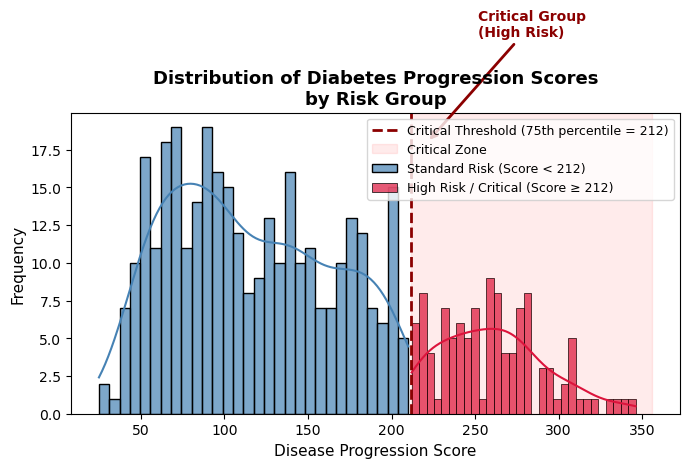

RISK GROUP SUMMARY
Standard Risk patients : 331 (74.9%)
Critical Risk patients : 111 (25.1%)
Standard Risk mean score : 115.7
Critical Risk mean score  : 260.6
Critical threshold (75th percentile): 212


In [96]:
# Distribution of Diabetes Progression Scores
#           Highlighting the Critical High-Risk Group
# PURPOSE: To show how disease severity is spread across all
#          patients and identify the high-risk group that
#          requires the most urgent clinical attention.

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the critical threshold (top 25% of scores = high risk)
critical_threshold = diabetes_data['target'].quantile(0.75)

plt.figure(figsize=(7, 5))

# Plot non-critical group (below threshold) in blue
sns.histplot(
    diabetes_data[diabetes_data['target'] < critical_threshold]['target'],
    bins=30,
    kde=True,
    color='steelblue',
    label=f'Standard Risk (Score < {critical_threshold:.0f})',
    alpha=0.7
)

# Plot critical group (above threshold) in red
sns.histplot(
    diabetes_data[diabetes_data['target'] >= critical_threshold]['target'],
    bins=30,
    kde=True,
    color='crimson',
    label=f'High Risk / Critical (Score ≥ {critical_threshold:.0f})',
    alpha=0.7
)

# Add a vertical threshold line
plt.axvline(
    x=critical_threshold,
    color='darkred',
    linestyle='--',
    linewidth=2,
    label=f'Critical Threshold (75th percentile = {critical_threshold:.0f})'
)

# Add a shaded region for the critical zone
plt.axvspan(
    critical_threshold,
    diabetes_data['target'].max() + 10,
    alpha=0.08,
    color='red',
    label='Critical Zone'
)

# Add annotation arrow pointing to critical zone
plt.annotate(
    'Critical Group\n(High Risk)',
    xy=(critical_threshold + 10, 18),
    xytext=(critical_threshold + 40, 25),
    arrowprops=dict(arrowstyle='->', color='darkred', lw=2),
    fontsize=10,
    fontweight='bold',
    color='darkred'
)

plt.title('Distribution of Diabetes Progression Scores\nby Risk Group', fontsize=13, fontweight='bold')
plt.xlabel('Disease Progression Score', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Print a summary of the two groups
print("=" * 45)
print("RISK GROUP SUMMARY")
print("=" * 45)
standard = diabetes_data[diabetes_data['target'] < critical_threshold]
critical = diabetes_data[diabetes_data['target'] >= critical_threshold]
print(f"Standard Risk patients : {len(standard)} ({len(standard)/len(diabetes_data)*100:.1f}%)")
print(f"Critical Risk patients : {len(critical)} ({len(critical)/len(diabetes_data)*100:.1f}%)")
print(f"Standard Risk mean score : {standard['target'].mean():.1f}")
print(f"Critical Risk mean score  : {critical['target'].mean():.1f}")
print(f"Critical threshold (75th percentile): {critical_threshold:.0f}")

Disease Progression Score (50–350)
Y-axis: Frequency — count of patients at each score
The distribution is right-skewed — most patients cluster between 50–150, 
but a long tail extends toward 350, meaning a smaller group has much worse progression.
A skewed target may require special handling in statistical models.

### Clinical Insights
The distribution is right-skewed — most patients cluster at lower scores (50–150),
but a smaller group has dramatically worse outcomes reaching up to 350.
This tells us two things:
First, the majority of patients have manageable disease progression.
Second, a high-risk minority exists whose disease has advanced significantly.
In healthcare, identifying and prioritizing this high-risk group early
is one of the most valuable things data analysis can do.
The red-highlighted critical zone (top 25%) represents the patients
who need the most urgent clinical attention. 


### Diabetes Progression by Hypertension Status ###

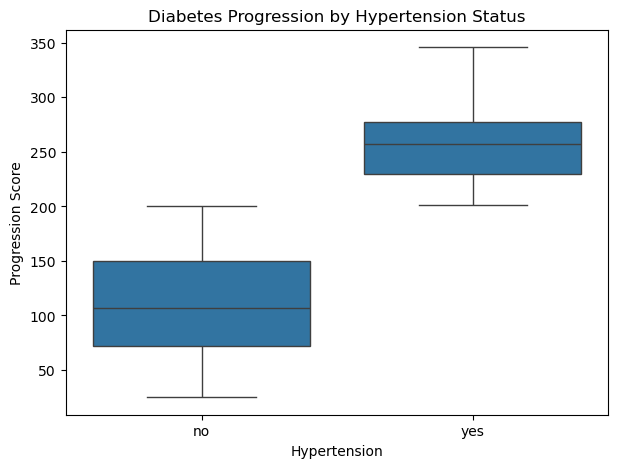

In [97]:
# Diabetes Progression by Hypertension Status
# PURPOSE: To determine whether having hypertension (high
#          blood pressure) is associated with significantly
#          worse diabetes outcomes — and by how much.

plt.figure(figsize=(7,5))
sns.boxplot(
    data=diabetes_data,
    x='hypertension',
    y='target'
)
plt.title('Diabetes Progression by Hypertension Status')
plt.xlabel('Hypertension')
plt.ylabel('Progression Score')
plt.show()

Patients with hypertension have a median score around 260, more than double the ~110 median of non-hypertensive patients. 
The boxes barely overlap, showing a strong separation.
This is one of the strongest findings in the entire dataset. 
Hypertension is clearly associated with much worse diabetes outcomes, making it a key variable for any predictive model.

### clinical insights
This confirms that higher BMI is closely linked to hypertension in this dataset. 
Combined with the previous findings, a picture emerges of a cluster of interconnected risk factors: 
high BMI → high blood pressure → hypertension → worse diabetes progression. 
This chain of related risks is well-documented in medical literature and is clearly visible in this data.


### BMI vs. Blood Pressure by Hypertension Status ###

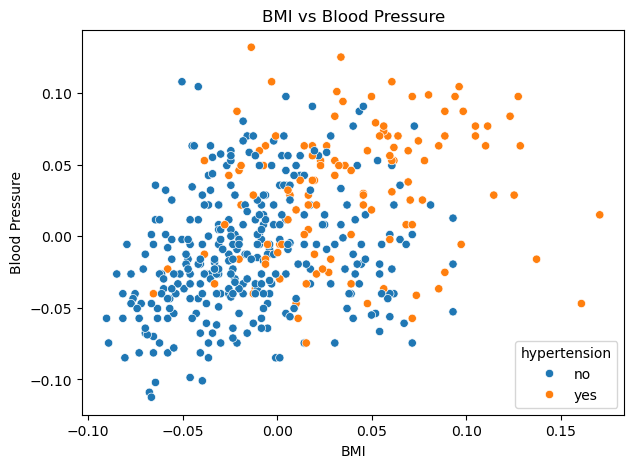

In [98]:
# BMI vs. Blood Pressure by Hypertension Status
# PURPOSE: To explore how BMI and blood pressure interact
#          with each other, and whether hypertensive patients
#          cluster differently from non-hypertensive patients
#          across these two risk factors simultaneously.

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=diabetes_data,
    x='bmi',
    y='bp',
    hue='hypertension'
)
plt.title('BMI vs Blood Pressure')
plt.xlabel('BMI')
plt.ylabel('Blood Pressure')
plt.show()


X-axis: BMI (body mass index) — normalized values, higher = heavier
Y-axis: Blood Pressure — normalized values, higher = higher BP
Orange dots (hypertensive patients) cluster toward higher BMI and higher blood pressure values
while blue dots (non-hypertensive) are more spread across lower ranges.
Shows that hypertension is not random — it tends to co-occur with both higher BMI and higher blood pressure, 
revealing how these three risk factors interact together.

### Clinical Insights
Orange dots (hypertensive patients) cluster toward the upper right of the chart —
meaning they tend to have BOTH higher BMI and higher blood pressure at the same time.
Blue dots (non-hypertensive patients) are spread more broadly
across lower BMI and lower blood pressure ranges.
This tells us hypertension does not appear randomly in this dataset —
it tends to show up in patients who are already heavier and have higher blood pressure.
Think of it like a warning signal: when BMI goes up and blood pressure goes up,
hypertension is likely to follow.
This interconnection between three risk factors must be considered carefully
when building prediction models, to avoid counting the same risk twice.

### BMI vs. Diabetes Progression Score ###

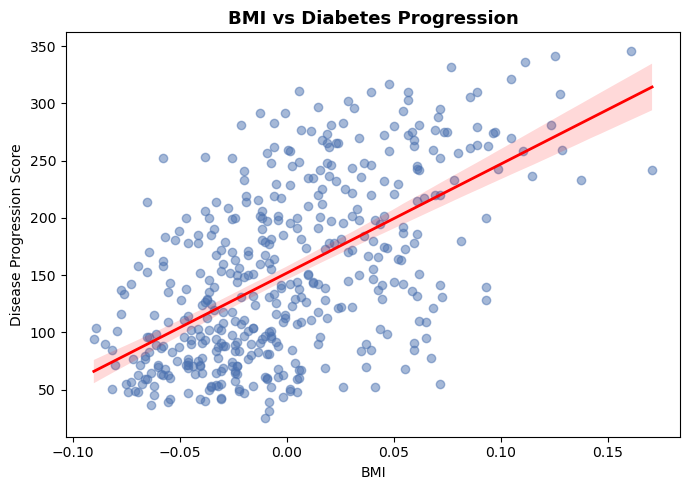

In [100]:
# BMI vs. Diabetes Progression Score
# PURPOSE: To measure how strongly BMI (body weight relative
#          to height) predicts diabetes severity, and confirm
#          whether it is the most powerful continuous
#          predictor in the dataset.

plt.figure(figsize=(7, 5))
sns.regplot(
    data=diabetes_data,
    x='bmi',
    y='target',
    scatter_kws={'alpha': 0.5, 'color': '#4C72B0'},
    line_kws={'color': 'red', 'linewidth': 2}
)
plt.title('BMI vs Diabetes Progression', fontsize=13, fontweight='bold')
plt.xlabel('BMI')
plt.ylabel('Disease Progression Score')
plt.tight_layout()
plt.show()

X-axis: BMI — normalized values
Y-axis: Disease Progression Score
A clear upward slope with a relatively tight confidence band. As BMI increases, progression scores rise consistently. 
This is the strongest predictor relationship in the dataset (correlation r = 0.59).
BMI is the single most powerful continuous predictor of diabetes progression. 
This chart justifies prioritizing BMI as a primary feature in any prediction model and supports the clinical importance of weight management.

### Clinical Insights
This chart shows the clearest and most consistent relationship in the entire dataset.
As BMI increases, diabetes progression scores increase steadily and reliably.
The correlation is r = 0.59 — the strongest of any single continuous variable.
The confidence band around the regression line is tight,
meaning this relationship holds consistently across the full range of patients,
not just in a few extreme cases.
In plain terms: heavier patients in this dataset have significantly worse
diabetes outcomes than lighter patients.
This strongly supports the well-established medical understanding
that obesity is a major driver of diabetes severity.
BMI should be the primary feature in any prediction model built from this data.

### BMI Distribution by Hypertension Status ###

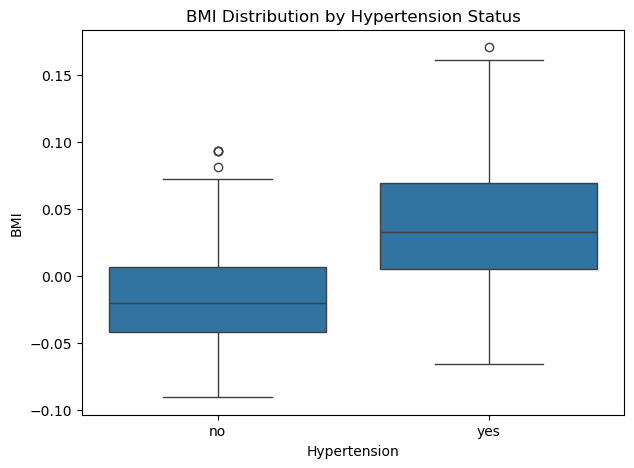

In [102]:
# BMI Distribution by Hypertension Status
# PURPOSE: To confirm whether hypertensive patients are
#          consistently heavier than non-hypertensive patients,
#          and to illustrate the chain of interconnected risk
#          factors linking BMI, blood pressure, and diabetes.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.boxplot(
    data=diabetes_data,
    x='hypertension',
    y='bmi'
)
plt.title('BMI Distribution by Hypertension Status')
plt.xlabel('Hypertension')
plt.ylabel('BMI')
plt.show()


X-axis: Hypertension status — "no" or "yes"
Y-axis: BMI values
Hypertensive patients (yes) have a clearly higher median BMI and a tight interquartile range centered above zero. 
Non-hypertensive patients show a lower, more spread-out BMI range with two outliers.
Confirms that higher BMI is associated with hypertension in this dataset. 
This means BMI, blood pressure, and hypertension are all related
which must be considered when building models to avoid including redundant information.

### Clinical Insights
This confirms that higher BMI is closely linked to hypertension in this dataset.
patients WITH hypertension have a clearly higher and more consistently elevated BMI.
Patients WITHOUT hypertension have a lower and more spread-out BMI range.
Combined with the previous findings, a picture emerges of a cluster
of interconnected risk factors:
high BMI → high blood pressure → hypertension → worse diabetes progression.
This chain of related risks is well-documented in medical literature
and is clearly visible in this data.
From a prevention standpoint, this means that weight management
could be one of the most effective interventions
to reduce hypertension AND slow diabetes progression at the same time.

### Correlation Heatmap of Clinical Variables ###

In [105]:
# Correlation Heatmap of Clinical Variables
# PURPOSE: To measure the strength of relationships between
#          ALL numeric variables at once, identify the top
#          predictors of diabetes progression, and flag
#          redundant variables that carry duplicate
#          information before building prediction models.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
diabetes_data = pd.read_excel('Diabetes_data.xlsx')

# Rename columns
new_column_names = {
    's1': 'total_cholesterol',
    's2': 'ldl',
    's3': 'hdl',
    's4': 'tch_hdl_ratio',
    's5': 'log_serum_triglycerides',
    's6': 'blood_sugar_level'
}
diabetes_data.rename(columns=new_column_names, inplace=True)

# Clean missing values
diabetes_data['age'] = diabetes_data['age'].fillna(diabetes_data['age'].mean())
diabetes_data['bmi'] = diabetes_data['bmi'].fillna(diabetes_data['bmi'].mean())
diabetes_data[['ldl', 'hdl']] = diabetes_data[['ldl', 'hdl']].fillna(0)

# Fix outlier age > 120
mean_age_clean = diabetes_data[diabetes_data['age'] <= 120]['age'].mean()
diabetes_data['age'] = diabetes_data['age'].apply(
    lambda x: mean_age_clean if x > 120 else x
)

print("Ready! Shape:", diabetes_data.shape)
print("Columns:", diabetes_data.columns.tolist())

Ready! Shape: (442, 15)
Columns: ['PID', 'age', 'sex', 'bmi', 'bp', 'total_cholesterol', 'ldl', 'hdl', 'tch_hdl_ratio', 'log_serum_triglycerides', 'blood_sugar_level', 'target', 'smoking_status', 'insurance', 'hypertension']


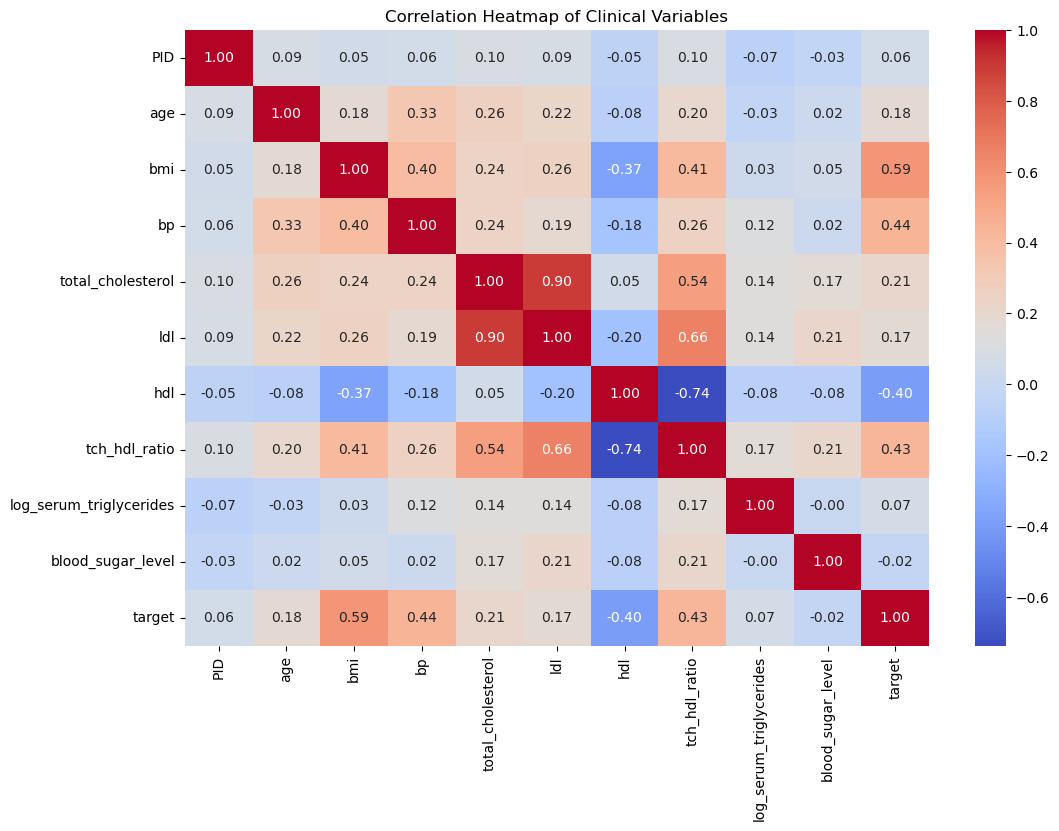

In [106]:
# Select numerical columns
num_cols = diabetes_data.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12,8))
sns.heatmap(
    num_cols.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap of Clinical Variables')
plt.show()


X-axis and Y-axis: All numeric variables in the dataset
Color scale: Red = strong positive correlation, Blue = strong negative correlation, White = no correlation
Description: Each cell shows how strongly two variables are related. Key findings: BMI–target (0.59), total cholesterol–LDL (0.90), HDL–TCH/HDL ratio (-0.74), blood pressure–target (0.44).
Essential for identifying which variables predict progression and which variables are redundant. 
For example, total cholesterol and LDL are so highly correlated (0.90) that including both in a model would be redundant.


### Clinical Insights
The heatmap reveals two critical things at once:
which variables best predict diabetes progression,
and which variables carry redundant information.

TOP PREDICTORS of diabetes progression (target):
BMI: r = 0.59 — strongest predictor, confirmed across multiple charts.
Blood pressure: r = 0.44 — second strongest continuous predictor.
TCH/HDL ratio: r = 0.43 — also a meaningful predictor.
HDL: r = -0.40 — negatively correlated, meaning higher HDL is protective.

REDUNDANT VARIABLE PAIRS to watch out for:
Total cholesterol and LDL: r = 0.90 — nearly identical information.
Including both in a model would be like counting the same risk factor twice.
HDL and TCH/HDL ratio: r = -0.74 — strongly related, use one or the other.

The takeaway for model building:
Prioritize BMI, blood pressure, and hypertension as primary features.
Choose either total cholesterol OR LDL, not both.
Age and sex contribute very little and may not be worth including.



### Gender based differences in Disease progression ###

Sex based differences in Disease progression
compares the distribution of diabetes progression scores between male and female patients. T
The width of each violin at any point shows how many patients have that progression score 

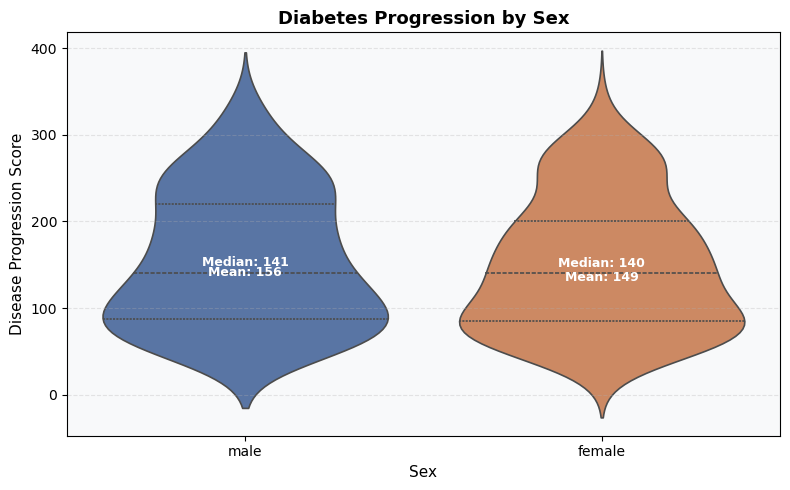

In [110]:
#  #sex based differences in Disease progression
#compares the distribution of diabetes progression scores between male and female patients. T
#The width of each violin at any point shows how many patients have that progression score 
# PURPOSE: To compare the full distribution of diabetes
#          progression scores between male and female patients
#          and determine whether sex is a meaningful
#          differentiator of disease outcomes in this dataset.

fig, ax = plt.subplots(figsize=(8, 5))

sns.violinplot(
    data=diabetes_data,
    x='sex',
    y='target',
    hue='sex',
    order=['male', 'female'],
    palette={'male': '#4C72B0', 'female': '#DD8452'},
    inner='quartile',
    linewidth=1.2,
    legend=False,
    ax=ax
)

# Add median and mean labels for each sex
for i, sex in enumerate(['male', 'female']):
    subset = diabetes_data[diabetes_data['sex'] == sex]['target']
    median = subset.median()
    mean   = subset.mean()
    ax.text(i, median + 8, f'Median: {median:.0f}',
            ha='center', color='white', fontsize=9, fontweight='bold')
    ax.text(i, mean - 18, f'Mean: {mean:.0f}',
            ha='center', color='white', fontsize=9, fontweight='bold')

ax.set_title('Diabetes Progression by Sex', fontsize=13, fontweight='bold')
ax.set_xlabel('Sex', fontsize=11)
ax.set_ylabel('Disease Progression Score', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.show()


This chart shows that in this particular dataset, sex does not appear to be a strong driver of diabetes progression.

### Clinical Insights
Male patients: median 141, mean 156.
Female patients: median 140, mean 149.
The shapes of both violin plots are nearly identical,
and the difference between groups is less than 10 points for both median and mean.
Both groups share the same right-skewed pattern —
most patients cluster at lower scores, with a tail reaching toward 350–400.
Sex does not appear to be a meaningful differentiator
of diabetes progression in this dataset.
This does not mean sex is never clinically relevant in diabetes research —
in larger or more diverse datasets, differences may emerge.
For this specific dataset, sex should be treated as a low-priority variable
and is unlikely to improve prediction model performance significantly.

### Categorical Variable Distributions (Pie Charts) ###

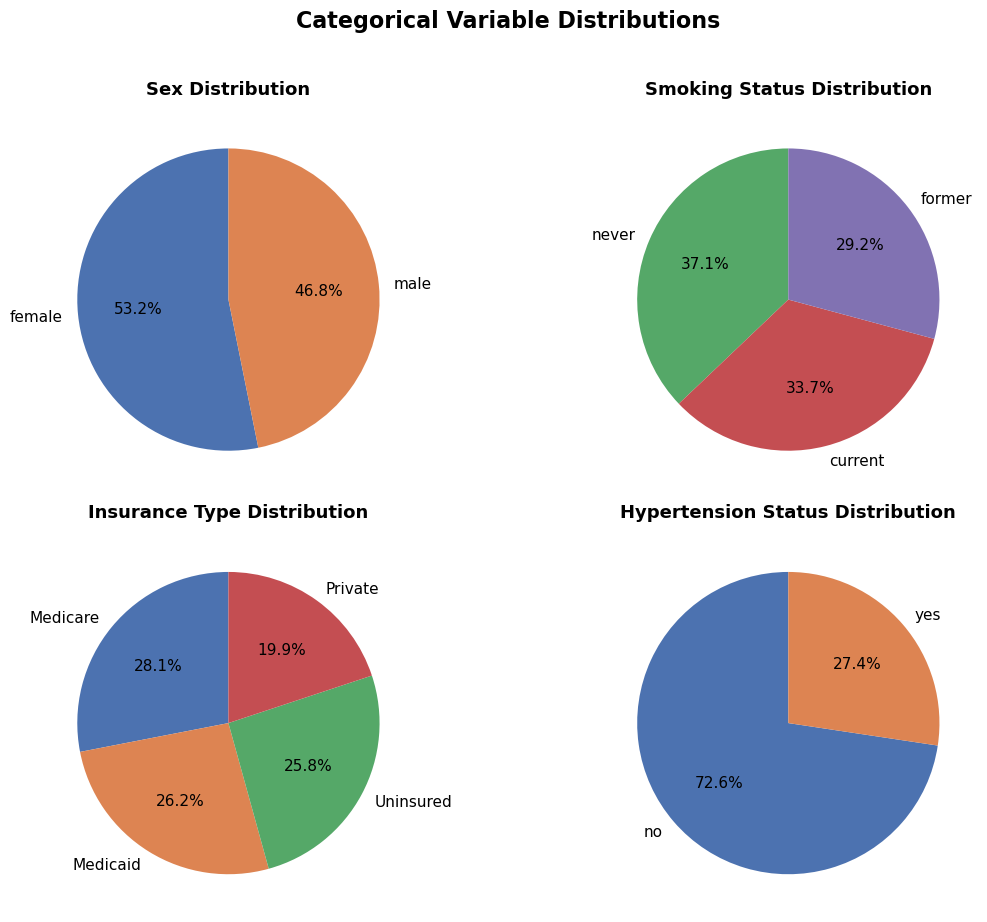

In [116]:
#Categorical Variable Distributions (Pie Charts)

# PURPOSE: To display the proportional breakdown of all four
#          categorical variables — sex, smoking status,
#          insurance type, and hypertension — to assess
#          group balance and flag any class imbalances
#          that could affect model performance.
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
cat_info = [
    ('sex',            'Sex Distribution'),
    ('smoking_status', 'Smoking Status Distribution'),
    ('insurance',      'Insurance Type Distribution'),
    ('hypertension',   'Hypertension Status Distribution'),
]
colors_list = [
    ['#4C72B0', '#DD8452'],
    ['#55A868', '#C44E52', '#8172B2'],
    ['#4C72B0', '#DD8452', '#55A868', '#C44E52'],
    ['#4C72B0', '#DD8452'],
]

for ax, (col, title), colors in zip(axes.flatten(), cat_info, colors_list):
    counts = diabetes_data[col].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
           colors=colors[:len(counts)], startangle=90,
           textprops={'fontsize': 11})
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)

plt.suptitle('Categorical Variable Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Shows the proportional breakdown of all four categorical variables.
Immediately flags class imbalances (e.g., 72% no-hypertension vs 28% yes)
Sex is 53.2% female / 46.8% male. 
Smoking is fairly balanced. Insurance is spread across four types with Medicare highest at 28.1%. 
Hypertension is heavily imbalanced at 72.6% no vs 27.4% yes.

### Clinical Insights
The four pie charts reveal the demographic makeup of this dataset.

SEX: 53.2% female, 46.8% male — nearly balanced.
This is good for analysis because neither group dominates the data.

SMOKING STATUS: Never 37.1%, Current 33.7%, Former 29.2% — fairly balanced.
All three groups are well-represented, making comparisons reliable.

INSURANCE TYPE: Medicare 28.1%, Medicaid 26.2%, Uninsured 25.8%, Private 19.9%.
Relatively even spread, though private insurance is underrepresented.
This may reflect that the dataset was collected from a public health setting.

HYPERTENSION: No 72.6%, Yes 27.4% — HEAVILY IMBALANCED.
This is the most important observation from these charts.
A model that simply guesses "no hypertension" every time
would be correct 72.6% of the time without learning anything useful.
This class imbalance must be addressed before building any classification model
that uses hypertension as a target or key feature.
Techniques like oversampling, weighted models, or adjusted evaluation metrics
will be necessary to handle this imbalance properly.
